# Model Inference — final submission


In [1]:

%pip install -q seaborn mlflow dagshub lightgbm xgboost



Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, gc, json, time, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow

import preprocessing as prep
import evaluation as ev
from preprocessing import BASE_COLS, MD_COLS, WalmartFeatureBuilder, \
    feature_columns, log1p_clip, expm1_inv, calendar_frame
from evaluation import wmae

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
sns.set_style("whitegrid")
SEED = 42
np.random.seed(SEED)
os.makedirs("pictures", exist_ok=True)

CODE_PATHS = ["preprocessing.py", "evaluation.py"]

ARCH = "Inference"


C:\Users\Test\ML\ML FINAL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import dagshub

DAGSHUB_USER = "rkvit23"
DAGSHUB_REPO = "ML-FINAL"

dagshub.init(repo_owner=DAGSHUB_USER, repo_name=DAGSHUB_REPO, mlflow=True)
mlflow.set_tracking_uri(f"https://dagshub.com/{DAGSHUB_USER}/{DAGSHUB_REPO}.mlflow")

EXPERIMENT_NAME = f"{ARCH}_Training"
mlflow.set_experiment(EXPERIMENT_NAME)
print("MLflow experiment:", EXPERIMENT_NAME)


Accessing as rkvit23

Initialized MLflow to track repo "rkvit23/ML-FINAL"

Repository rkvit23/ML-FINAL initialized!

2026/07/11 23:08:05 INFO mlflow.tracking.fluent: Experiment with name 'Inference_Training' does not exist. Creating a new experiment.


MLflow experiment: Inference_Training


In [4]:
train_raw, test_raw, features_raw, stores_raw = prep.load_data()

TRAIN_START, TRAIN_END = train_raw.Date.min(), train_raw.Date.max()
TEST_START,  TEST_END  = test_raw.Date.min(),  test_raw.Date.max()
HORIZON = test_raw.Date.nunique()      # 39 weeks

print("train:", train_raw.shape, TRAIN_START.date(), "->", TRAIN_END.date(),
      "| weeks:", train_raw.Date.nunique())
print("test :", test_raw.shape,  TEST_START.date(),  "->", TEST_END.date(),
      "| weeks:", HORIZON)
print("series (Store, Dept) in train:", train_raw.groupby(["Store", "Dept"]).ngroups)


train: (421570, 5) 2010-02-05 -> 2012-10-26 | weeks: 143
test : (115064, 4) 2012-11-02 -> 2013-07-26 | weeks: 39
series (Store, Dept) in train: 3331


## Load the model from the Model Registry

In [5]:
MODEL_NAME = "WalmartBestModel"
MODEL_VERSION = "latest"        # <--- or a specific version, e.g. "1"

client = mlflow.tracking.MlflowClient()
versions = client.search_model_versions(f"name='{MODEL_NAME}'")
print("Versions in the Registry:")
for v in versions:
    print(f"  v{v.version} | run_id={v.run_id} | {v.source}")

if MODEL_VERSION == "latest":
    MODEL_VERSION = max(int(v.version) for v in versions)
MODEL_URI = f"models:/{MODEL_NAME}/{MODEL_VERSION}"
print("\nloading:", MODEL_URI)

model = mlflow.pyfunc.load_model(MODEL_URI)
print("model loaded:", type(model))


Versions in the Registry:
  v1 | run_id=a53995d3e60d40c3963f517fd1a81ebf | models:/m-f6df05170ab84e87b786be7f74263eb2

loading: models:/WalmartBestModel/1


model loaded: <class 'mlflow.pyfunc.PyFuncModel'>


In [6]:
t0 = time.time()
test_pred = np.asarray(model.predict(test_raw[["Store", "Dept", "Date", "IsHoliday"]]))
print(f"predicted {len(test_pred):,} rows in {time.time()-t0:.1f}s")
assert len(test_pred) == len(test_raw) and np.isfinite(test_pred).all()

sub = ev.make_submission(test_raw, test_pred, "submission.csv")
print(sub.head())
print("saved: submission.csv")


predicted 115,064 rows in 1.7s
               Id  Weekly_Sales
0  1_1_2012-11-02  35672.515953
1  1_1_2012-11-09  20469.472524
2  1_1_2012-11-16  19583.699046
3  1_1_2012-11-23  19428.927108
4  1_1_2012-11-30  23542.364224
saved: submission.csv


In [7]:
# 2.5/7 blend of weeks 49-52 with the previous week (see evaluation.apply_christmas_shift).
APPLY_XMAS_SHIFT = True

if APPLY_XMAS_SHIFT:
    sub_shift = ev.apply_christmas_shift(sub, test_raw)
    sub_shift.to_csv("submission_xmas_shift.csv", index=False)
    print("saved: submission_xmas_shift.csv")


saved: submission_xmas_shift.csv


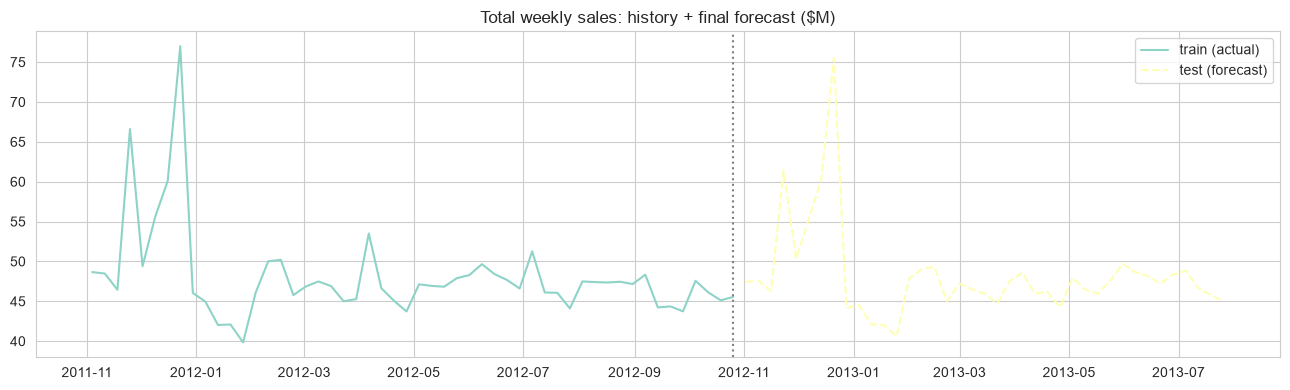

In [8]:
# Visual sanity check: last train year + the test forecast
fig, ax = plt.subplots(figsize=(13, 4))
hist_tot = train_raw[train_raw.Date >= "2011-11-01"].groupby("Date").Weekly_Sales.sum() / 1e6
pred_tot = pd.Series(test_pred, index=test_raw.Date).groupby(level=0).sum() / 1e6
ax.plot(hist_tot.index, hist_tot.values, label="train (actual)")
ax.plot(pred_tot.index, pred_tot.values, "--", label="test (forecast)")
ax.axvline(TRAIN_END, color="gray", ls=":")
ax.set_title("Total weekly sales: history + final forecast ($M)")
ax.legend()
plt.tight_layout(); plt.savefig("pictures/final_forecast.png", dpi=120); plt.show()
